In [1]:
import torch
from torch import nn
import numpy as np
from scipy.stats import ortho_group
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
def generate_normalized_structured_data(n_samples=10000, n_features=30, n_hidden=15):
    X = np.random.randn(n_samples, n_features)
    W = np.zeros((n_hidden, n_features))
    a = np.zeros(n_hidden)

    # 1. Create an Orthonormal Basis for W
    # This ensures features are not redundant/collinear
    full_ortho = ortho_group.rvs(dim=n_features)
    W = full_ortho[:n_hidden, :] # Shape (n_hidden, n_features)

    # 2. Define structured importance (a_i)
    # Let's make 4 "heavy" features and 6 "light" features
    a = np.zeros(n_hidden)
    strong = n_hidden // 2
    a[:strong] = np.random.uniform(2, 3, size=strong)  # Strong Signal
    a[strong:] = np.random.uniform(0.1, 0.5, size=n_hidden-strong) # Weak Signal/Noise

    # Random biases for hidden units
    b1 = np.random.uniform(-1, 1, size=n_hidden)

    # 2. Raw Forward Pass (using ReLU as an example)
    Z = np.maximum(0, X @ W.T + b1) # hidden layer pre-activations
    raw_logits = Z @ a

    # 3. Calculate Scaling Factor
    # We want std(logits) to be, say, 2.0 for a clear but soft boundary
    target_std = 1.0
    current_std = np.std(raw_logits)
    scaling_factor = target_std / current_std

    # 4. POST-HOC WEIGHT NORMALIZATION
    # This scales the weights so the resulting function naturally outputs
    # normalized values.
    a_normalized = a * scaling_factor

    # 5. Final Calculation with normalized weights
    final_logits = Z @ a_normalized
    # Center them using a single scalar shift (effectively an output bias)
    b2 = - np.mean(final_logits)
    final_logits += b2

    probs = 1 / (1 + np.exp(-final_logits))
    y = (probs > 0.5).astype(int)

    print(f"Logit Std Dev: {np.std(X @ W.T @ a_normalized):.2f}") # Should be ~2.0
    print(f"Class 1 Ratio: {np.mean(y):.2%}")

    teacher_model = nn.Sequential(nn.Linear(n_features, n_hidden), nn.ReLU(), nn.Linear(n_hidden, 1))

    # Load the teacher_params into the teacher_model
    with torch.no_grad():
        # First linear layer: W and b1
        teacher_model[0].weight.copy_(torch.from_numpy(W).float())
        teacher_model[0].bias.copy_(torch.from_numpy(b1).float())

        # Second linear layer: a_normalized and b2
        # Note: a_normalized is a 1D array, so we need to reshape it to (output_dim, hidden_dim) for the weight matrix
        # And b2 is a scalar, so we need to reshape it to (output_dim,)
        teacher_model[2].weight.copy_(torch.from_numpy(a_normalized).float().unsqueeze(0))
        teacher_model[2].bias.copy_(torch.from_numpy(np.array([b2])).float())

    print("Teacher model parameters loaded successfully.")


    return train_test_split(X, y, test_size=0.2, random_state=42), (W, a_normalized, b1, b2)

# Generate the data
# X_gen, y_gen, params = generate_custom_nn_data()
(X_train_gen, X_test_gen, y_train_gen, y_test_gen), teacher_params = generate_normalized_structured_data()


Logit Std Dev: 1.58
Class 1 Ratio: 46.71%
Teacher model parameters loaded successfully.


In [ ]:
# # add random label noise
# rand_idx = np.random.permutation(np.arange(len(y_train_gen)))[:len(y_train_gen)//10]
# y_train_gen[rand_idx] = y_train_gen[rand_idx]*(-1) + 1 # flip 0,1 labels

In [53]:
X_train = X_train_gen.astype(np.float32)
y_train = y_train_gen
X_test = X_test_gen.astype(np.float32)
y_test = y_test_gen

In [55]:
print(b1)
print(b2)

[ 0.95197673  0.50106581 -0.50492497  0.97411031  0.05021527 -0.43930631
  0.0272993  -0.99807321 -0.64815568  0.42913319 -0.13404831 -0.46485473
 -0.64969476  0.89520326  0.6223802 ]
-2.4787148888761434


In [56]:
from torch.utils.data import Dataset, DataLoader

class MyCustomDataset(Dataset):
    def __init__(self, data_list, labels):
        self.data = data_list
        self.labels = labels

    def __len__(self):
        # Return the total number of samples
        return len(self.data)

    def __getitem__(self, idx):
        # Load one sample and its label
        sample = torch.tensor(self.data[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return sample, label, idx

In [57]:
hidden_dim = 15
input_dim = 30
output_dim = 1

In [58]:
model = nn.Sequential(nn.Linear(input_dim,hidden_dim), nn.ReLU(), nn.Linear(hidden_dim,output_dim))
student_model = nn.Sequential(nn.Linear(input_dim,hidden_dim), nn.ReLU(), nn.Linear(hidden_dim,output_dim))
student_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [59]:
epochs = 300
batch_size = 320
lr = 1e-3
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(student_model.parameters(), lr = lr)

In [60]:
train_set = MyCustomDataset(X_train, y_train)
test_set = MyCustomDataset(X_test, y_test)
dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

In [78]:
criterion_per_sample = nn.BCELoss(reduction="none")


with torch.no_grad():
        teacher_logits = teacher_model(torch.from_numpy(train_set.data))
        teacher_probs = (torch.sigmoid(teacher_logits).squeeze() > 0.5).long()
        teacher_losses = criterion_per_sample(teacher_probs.float(), torch.from_numpy(y_train).float())

In [61]:
full_train_accuracy = []
full_test_accuracy = []
full_train_logits = []
full_test_logits = []
for epoch in range(epochs):
    student_model.train()
    for i, (data,targets,idx) in enumerate(dataloader):
        optimizer.zero_grad()
        outputs = student_model(data)
        pred_probabilities = torch.sigmoid(outputs).squeeze()
        # Cast targets to float for BCELoss
        loss = criterion(pred_probabilities, targets.float())

        loss.backward()
        optimizer.step()

    student_model.eval()
    with torch.no_grad():
        # For binary classification with output_dim=1, and if BCELoss is used without a final Sigmoid in the model,
        # outputs are logits. Apply sigmoid to get probabilities, then threshold at 0.5 for binary prediction.
        outputs_train_logits = student_model(torch.from_numpy(train_set.data))
        predicted_train = (torch.sigmoid(outputs_train_logits).squeeze() > 0.5).long()
        full_train_accuracy.append(((predicted_train == torch.from_numpy(train_set.labels).long()).sum().item() / len(train_set)))
        full_train_logits.append(torch.mean(torch.abs(outputs_train_logits)))
        outputs_test_logits = student_model(torch.from_numpy(test_set.data))
        predicted_test = (torch.sigmoid(outputs_test_logits).squeeze() > 0.5).long()
        full_test_accuracy.append(((predicted_test == torch.from_numpy(test_set.labels).long()).sum().item() / len(test_set)))
        full_test_logits.append(torch.mean(torch.abs(outputs_test_logits)))


In [62]:
# teacher_model = nn.Sequential(nn.Linear(input_dim,hidden_dim), nn.ReLU(), nn.Linear(hidden_dim,output_dim))

# for epoch in range(epochs):
#     student_model.train()
#     for i, (data,targets,idx) in enumerate(test_dataloader):
#         optimizer.zero_grad()
#         outputs = teacher_model(data)
#         pred_probabilities = torch.sigmoid(outputs).squeeze()
#         loss = criterion(pred_probabilities, targets.float())

#         loss.backward()
#         optimizer.step()

In [63]:
student_model = nn.Sequential(nn.Linear(input_dim,hidden_dim), nn.ReLU(), nn.Linear(hidden_dim,output_dim))
student_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [64]:
criterion_per_sample = nn.BCELoss(reduction="none")
optimizer = torch.optim.Adam(student_model.parameters(), lr = lr)

In [65]:
rholoss_train_accuracy = []
rholoss_test_accuracy = []
rholoss_train_logits = []
rholoss_test_logits = []
for epoch in range(epochs):
    student_model.train()
    for i, (data,targets,idx) in enumerate(dataloader):
        optimizer.zero_grad()

        with torch.no_grad():
          outputs = student_model(data)
          student_probabilities = torch.sigmoid(outputs).squeeze()
          student_loss = criterion_per_sample(student_probabilities, targets.float())

          teacher_loss = teacher_losses[idx]

          # teacher_probabilities = teacher_probs[idx]
          # teacher_loss = criterion_per_sample(teacher_probabilities, targets.float())

          # teacher_outputs = teacher_model(data)
          # teacher_probabilities = torch.sigmoid(teacher_outputs).squeeze()
          # teacher_loss = criterion_per_sample(teacher_probabilities, targets.float())

          rholoss = student_loss - teacher_loss
          _, selected_indices = torch.topk(rholoss,k=len(data)//10)

          data = data[selected_indices]
          targets = targets[selected_indices]


        outputs = student_model(data)
        pred_probabilities = torch.sigmoid(outputs).squeeze()
        loss = criterion(pred_probabilities, targets.float())

        loss.backward()
        optimizer.step()

    student_model.eval()
    with torch.no_grad():
        outputs_train_logits = student_model(torch.from_numpy(train_set.data))
        predicted_train = (torch.sigmoid(outputs_train_logits).squeeze() > 0.5).long()
        rholoss_train_accuracy.append(((predicted_train == torch.from_numpy(train_set.labels).long()).sum().item() / len(train_set)))
        rholoss_train_logits.append(torch.mean(torch.abs(outputs_train_logits)))

        outputs_test_logits = student_model(torch.from_numpy(test_set.data))
        predicted_test = (torch.sigmoid(outputs_test_logits).squeeze() > 0.5).long()
        rholoss_test_accuracy.append(((predicted_test == torch.from_numpy(test_set.labels).long()).sum().item() / len(test_set)))
        rholoss_test_logits.append(torch.mean(torch.abs(outputs_test_logits)))

In [66]:
student_model = nn.Sequential(nn.Linear(input_dim,hidden_dim), nn.ReLU(), nn.Linear(hidden_dim,output_dim))
student_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [67]:
criterion_per_sample = nn.BCELoss(reduction="none")
optimizer = torch.optim.Adam(student_model.parameters(), lr = lr)

In [68]:
uniform_train_accuracy = []
uniform_test_accuracy = []
uniform_train_logits = []
uniform_test_logits = []
for epoch in range(epochs):
    student_model.train()
    for i, (data,targets,idx) in enumerate(dataloader):
        optimizer.zero_grad()

        with torch.no_grad():
          selected_indices = torch.randperm(len(data))[:len(data)//10]

          data = data[selected_indices]
          targets = targets[selected_indices]


        outputs = student_model(data)
        pred_probabilities = torch.sigmoid(outputs).squeeze()
        loss = criterion(pred_probabilities, targets.float())

        loss.backward()
        optimizer.step()

    student_model.eval()
    with torch.no_grad():
        outputs_train_logits = student_model(torch.from_numpy(train_set.data))
        predicted_train = (torch.sigmoid(outputs_train_logits).squeeze() > 0.5).long()
        uniform_train_accuracy.append(((predicted_train == torch.from_numpy(train_set.labels).long()).sum().item() / len(train_set)))
        uniform_train_logits.append(torch.mean(torch.abs(outputs_train_logits)))

        outputs_test_logits = student_model(torch.from_numpy(test_set.data))
        predicted_test = (torch.sigmoid(outputs_test_logits).squeeze() > 0.5).long()
        uniform_test_accuracy.append(((predicted_test == torch.from_numpy(test_set.labels).long()).sum().item() / len(test_set)))
        uniform_test_logits.append(torch.mean(torch.abs(outputs_test_logits)))

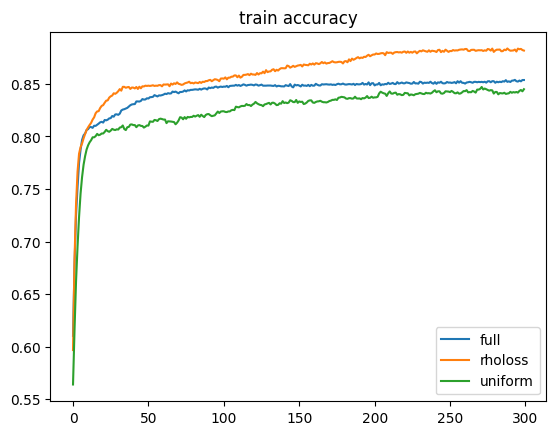

In [69]:
plt.plot(np.arange(len(full_train_accuracy)), full_train_accuracy, label='full')
plt.plot(np.arange(len(rholoss_train_accuracy)), rholoss_train_accuracy, label='rholoss')
plt.plot(np.arange(len(uniform_train_accuracy)), uniform_train_accuracy, label='uniform')

plt.legend()
plt.title('train accuracy')

plt.show()

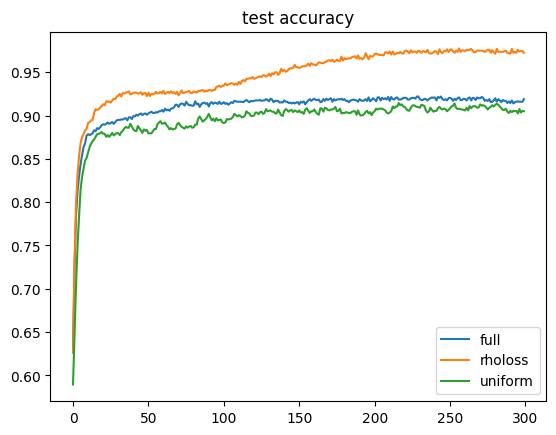

In [70]:
plt.plot(np.arange(len(full_test_accuracy)), full_test_accuracy, label='full')
plt.plot(np.arange(len(rholoss_test_accuracy)), rholoss_test_accuracy, label='rholoss')
plt.plot(np.arange(len(uniform_test_accuracy)), uniform_test_accuracy, label='uniform')

plt.legend()
plt.title('test accuracy')

plt.show()

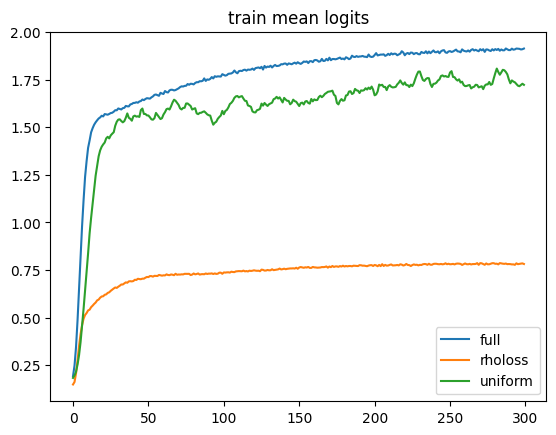

In [71]:
plt.plot(np.arange(len(full_train_logits)), full_train_logits, label='full')
plt.plot(np.arange(len(rholoss_train_logits)), rholoss_train_logits, label='rholoss')
plt.plot(np.arange(len(uniform_train_logits)), uniform_train_logits, label='uniform')

plt.legend()
plt.title('train mean logits')

plt.show()

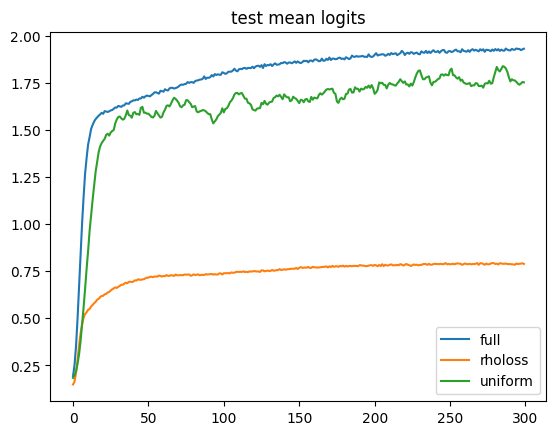

In [72]:
plt.plot(np.arange(len(full_test_logits)), full_test_logits, label='full')
plt.plot(np.arange(len(rholoss_test_logits)), rholoss_test_logits, label='rholoss')
plt.plot(np.arange(len(uniform_test_logits)), uniform_test_logits, label='uniform')

plt.legend()
plt.title('test mean logits')

plt.show()